# Jupyter Notebook for RNA-seq analysis

Author: Estelle Yao (yaon@mskcc.org)

Organized/uploaded by: Jayon Lihm (lihmj@mskcc.org)

Corresponding author: Samuel A. Funt (funts@mkscc.org)

In [2]:
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import fdrcorrection
import warnings
warnings.filterwarnings('ignore')
import subprocess
import os

from matplotlib.lines import Line2D
import matplotlib as mpl

from adjustText import adjust_text
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch

std_chr =  [f'chr{i}' for i in list(np.arange(1,24))+['X','Y']]

## Luminal vs Basal subclass
Function

In [3]:
def lum_bas(full):
    lum = full[full.index.isin(['KRT20','PPARG','FOXA1','GATA3','SNX31','UPK1A','UPK2','FGFR3',   ])]
    bas = full[full.index.isin(['KRT6','KRT5','COL17A1', 'CD44', 'DSC3','GSDMC','TGM1','PI3',])]
    
   # dif = pd.concat([annot_clean, ,axis= 1) 
    dif = pd.DataFrame( {'luminal': np.log2(lum.mean()),   'basal': np.log2(bas.mean())})
    dif['fc'] =dif['luminal'] - dif['basal']
    sub = full[full.index.isin(['KRT20','PPARG','FOXA1','GATA3','SNX31','UPK1A','UPK2','FGFR3',  ]+ ['KRT6','KRT5','COL17A1', 'CD44', 'DSC3','GSDMC','TGM1','PI3' ])][full.columns[full.columns.isin( dif.index )]]
    
    dif['subtype'] = 'Others'
    dif.loc[dif['fc']>= -1.4,'subtype'] = 'Luminal'
    dif.loc[dif['fc']<= -1.4,'subtype'] = 'Basal'
    dif['subtype_color'] = dif['subtype'].map({'Others':'grey','Luminal':'orange','Basal':'purple'})
    return dif

## Pre-processing

- Read raw counts data (counts.annot.tsv)
- Select protein coding genes
- Output table for DESEQ analysis (qc_pc_count.csv)

In [4]:
## read clinical annotation
clinc_annot = pd.read_csv('../data/rna_seq_data/patient_annotations.csv')

In [5]:
### Select Protein Coding (PC) read counts
ct = pd.read_csv('../data/rna_seq_data/counts_annot.tsv.gz', sep = "\t")
pc = ct[ct['gene.type'] == 'protein_coding']
pc.index = pc['gene.symbol']
pc_clean = pc.sort_values(by = ['length'],ascending = False).drop_duplicates(subset= ['gene.symbol'])

### Length of gene for TPM 
length = pc_clean[['gene.symbol','length']]
length['kb_length'] = length['length']/1000

pc_clean = pc_clean.drop(columns = ['gene.id', 'ensembl.gene.id', 'chr', 'gene.symbol', 'gene.type','length', 'description', 'entrez.gene.id', 'uniprot.id', 'go.gene.id'])

d = pd.DataFrame(pc_clean.T.sum())
pc_clean = pc_clean[pc_clean.index.isin(d[d[0]>10].index)]
clean_col = ['Patient' + k.split('.')[0].replace('X',"") for k in pc_clean.columns]
pc_clean.columns = clean_col

qc = pd.DataFrame(np.log10(pc_clean.mean(axis = 1))).sort_values(by = [0])
qc = qc[qc[0]>2].index

pc_qc = pc_clean[pc_clean.index.isin(qc)].drop(columns = ['Patient98'])
## select the patients with clinical annotation
pc_qc = pc_qc[clinc_annot.ID]
pc_qc.to_csv('../data/rna_seq_data/qc_pc_count_full.tsv', sep = '\t')

## DESEQ2

In [134]:
!Rscript ../src/rna/deseq.R "full" "../data/rna_seq_data/"

필요한 패키지를 로딩중입니다: S4Vectors
필요한 패키지를 로딩중입니다: stats4
필요한 패키지를 로딩중입니다: BiocGenerics

다음의 패키지를 부착합니다: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, saveRDS, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min


다음의 패키지를 부착합니다: ‘S4Vectors’

The following object is masked from ‘package:utils’:

    findMatches

The following objects are masked from ‘package:base’:

    I, expand.grid, unname

필요한 패키지를 로딩중입니다: IRanges
필요한 패키지를 로딩중입니다: GenomicRanges
필요한 패키지를 로딩중입니다: GenomeInfoDb
필요한 패키지를 로딩중입니다: SummarizedExperiment
필요한 패키지를 로딩중입니다: MatrixGenerics
필요

In [135]:
!Rscript ../src/rna/deseq.R "combofull" "../data/rna_seq_data/"

필요한 패키지를 로딩중입니다: S4Vectors
필요한 패키지를 로딩중입니다: stats4
필요한 패키지를 로딩중입니다: BiocGenerics

다음의 패키지를 부착합니다: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, saveRDS, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min


다음의 패키지를 부착합니다: ‘S4Vectors’

The following object is masked from ‘package:utils’:

    findMatches

The following objects are masked from ‘package:base’:

    I, expand.grid, unname

필요한 패키지를 로딩중입니다: IRanges
필요한 패키지를 로딩중입니다: GenomicRanges
필요한 패키지를 로딩중입니다: GenomeInfoDb
필요한 패키지를 로딩중입니다: SummarizedExperiment
필요한 패키지를 로딩중입니다: MatrixGenerics
필요

## Figure 2A

- Gene pathway, subset, color schemes definition

In [6]:
gene_subset = ['FGFR3','TP63','WNT7B',
                'CD8A','GZMA','PRF1','CXCL9','CXCL10','TBX21',
                'TAP1','TAP2','B2M','HLA-A','HLA-B','HLA-C','CD274','PDCD1LG2','CTLA4','PDCD1','LAG3','HAVCR2','TIGIT',
                'MKI67','CCNE1','BUB1','BUB1B','CCNB2','CDC25C','CDK2','MCM4','MCM6','MCM2',
                'TGFB1','TGFB2','ACTA2','COL4A1','TAGLN','SH3PXD2A',
                'BRCA2','ERCC2','FANCA','POLE','RAD51C',
                'CLDN4','CLDN3','CLDN7','VIM','TWIST1','ZEB1','ZEB2',
                'TEK','SOX17','SOX18','CDH5'
            ]

pathway_dict = {
    'FGFR3': ['FGFR3','TP63','WNT7B' ], #https://pmc.ncbi.nlm.nih.gov/articles/PMC12431237/
    'CD8+ T effector': [ 'CD8A','GZMA','PRF1','CXCL9','CXCL10','TBX21' ], 
    'APM': [ 'TAP1', 'TAP2', 'B2M', 'HLA-A', 'HLA-B', 'HLA-C' ],
    'Immune checkpoint': ['CD274', 'PDCD1LG2', 'CTLA4', 'PDCD1', 'LAG3', 'HAVCR2', 'TIGIT' ],
    'Cell cycle': ['MKI67', 'CCNE1', 'BUB1', 'BUB1B', 'CCNB2', 'CDC25C', 'CDK2', 'MCM4', 'MCM6', 'MCM2' ],
    'DDR': ['BRCA2', 'ERCC2', 'FANCA', 'POLE', 'RAD51C'],
    'TGFbeta': ['TGFB1', 'TGFB2' ],
    'F-TBRS': ['ACTA2', 'COL4A1', 'TAGLN', 'SH3PXD2A' ],
    'EMT': [ 'CLDN4', 'CLDN3', 'CLDN7', 'VIM', 'TWIST1', 'ZEB1', 'ZEB2' ],
    'Angiogenesis': ['TEK', 'SOX17', 'SOX18', 'CDH5']
}

color_list = ['gold','pink','violet','orange','teal','turquoise','deepskyblue','brown','seagreen','purple']

# Group annotations
gene_dict = {}
for gene_list, group in zip( pathway_dict.values(), pathway_dict.keys()):
    for gene in gene_list:
        gene_dict[gene] = group

# Color mapping
group_palette = {}
for group, color in zip (['FGFR3','CD8+ T effector','APM','Immune checkpoint','Cell cycle','DDR','TGFbeta','F-TBRS','EMT','Angiogenesis'],
                          color_list ):
    group_palette[group] = color

# Create legend handles
handles = [
    Patch(facecolor=color, label=group)
    for group, color in group_palette.items()
]

g_list =[] 
for col1,col2 in zip(pathway_dict.values(),
                          pathway_dict.keys()):
    g = pd.DataFrame({'gene': col1})
    g['name'] = col2
    g['color'] = group_palette[col2]
    g_list.append(g)

gdf = pd.concat(g_list)
gdf.index = gdf.gene

subtype_color_dict= {}
for a,b in zip(group_palette.keys(), group_palette.values()):
    subtype_color_dict[a] = b

- Read patient annotation and assign TC/IC group

In [7]:
m15126_annot= pd.read_csv("../data/rna_seq_data/patient_annotations.csv")

m15126_annot['TC (%)'] = m15126_annot['TC (%)'].astype(float)
m15126_annot['IC (%)'] = m15126_annot['IC (%)'].astype(float)

m15126_annot['TC'] = "Others"
m15126_annot.loc[(m15126_annot['TC (%)']<1),'TC'] = 'TC0'
m15126_annot.loc[(m15126_annot['TC (%)']<5)*(m15126_annot['TC (%)']>=1),'TC'] = 'TC1'
m15126_annot.loc[(m15126_annot['TC (%)']>=5),'TC'] = 'TC2'

m15126_annot['IC'] = "Others"
m15126_annot.loc[(m15126_annot['IC (%)']<1),'IC'] = 'IC0'
m15126_annot.loc[(m15126_annot['IC (%)']<5)*(m15126_annot['IC (%)']>=1),'IC'] = 'IC1'
m15126_annot.loc[(m15126_annot['IC (%)']>=5),'IC'] = 'IC2'

m15126_annot.index = m15126_annot.ID


- Read DEseq result and normalized counts values for heatmap

In [8]:
m15126 = (pd.read_csv('../data/rna_seq_data/deseq_output/deseq_result_pc_full.csv',sep = ','))
m15126_full = (pd.read_csv('../data/rna_seq_data/deseq_output/dds_pc_normalize_full.csv',sep = ','))
m15126_full.index = m15126['ID']
m15126_dif = lum_bas(m15126_full)

m15126_annot= pd.concat([m15126_annot,
                         m15126_dif],axis= 1)

- Assing colors for top rows

In [9]:
m15126_exp = pd.concat([ m15126_annot, np.log2(m15126_full.T+1)], axis= 1).copy()
m15126_exp = m15126_exp.dropna(subset=['response'])
m15126_exp['response_color'] = m15126_exp['response'].map({'Responder':'skyblue','Non-responder':'deeppink'})
m15126_exp['combo_color'] = m15126_exp['combo_best_response_clean'].map({'PR':'skyblue','CR':'skyblue',
                                                                         'PD':'deeppink', 'SD':'deeppink','NE':'deeppink'})
m15126_exp['IC_color'] = m15126_exp['IC'].map({'IC0':'lightgrey','IC1':'salmon','IC2':'brown'})
m15126_exp['TC_color'] = m15126_exp['TC'].map({'TC0':'lightgrey','TC1':'turquoise','TC2':'forestgreen'})


- Take gene subset and normalize

In [10]:
subset = m15126_exp[gene_subset]
z = (subset - subset.mean())/subset.std()

- Create TMB bars and TP53 mutation status

In [11]:
mut = pd.read_csv('../data/wes_summary_data/freq_mutated_genes_Oncoprint.csv', sep = ',',
                  index_col=0)
m15126_exp = pd.concat([mut, m15126_exp ], axis= 1).dropna(subset=['response'])


## mutation color assignment
m15126_exp['TP53_color'] = m15126_exp['TP53_mut'].map({True:'black',False:'white'})

- Create heatmap

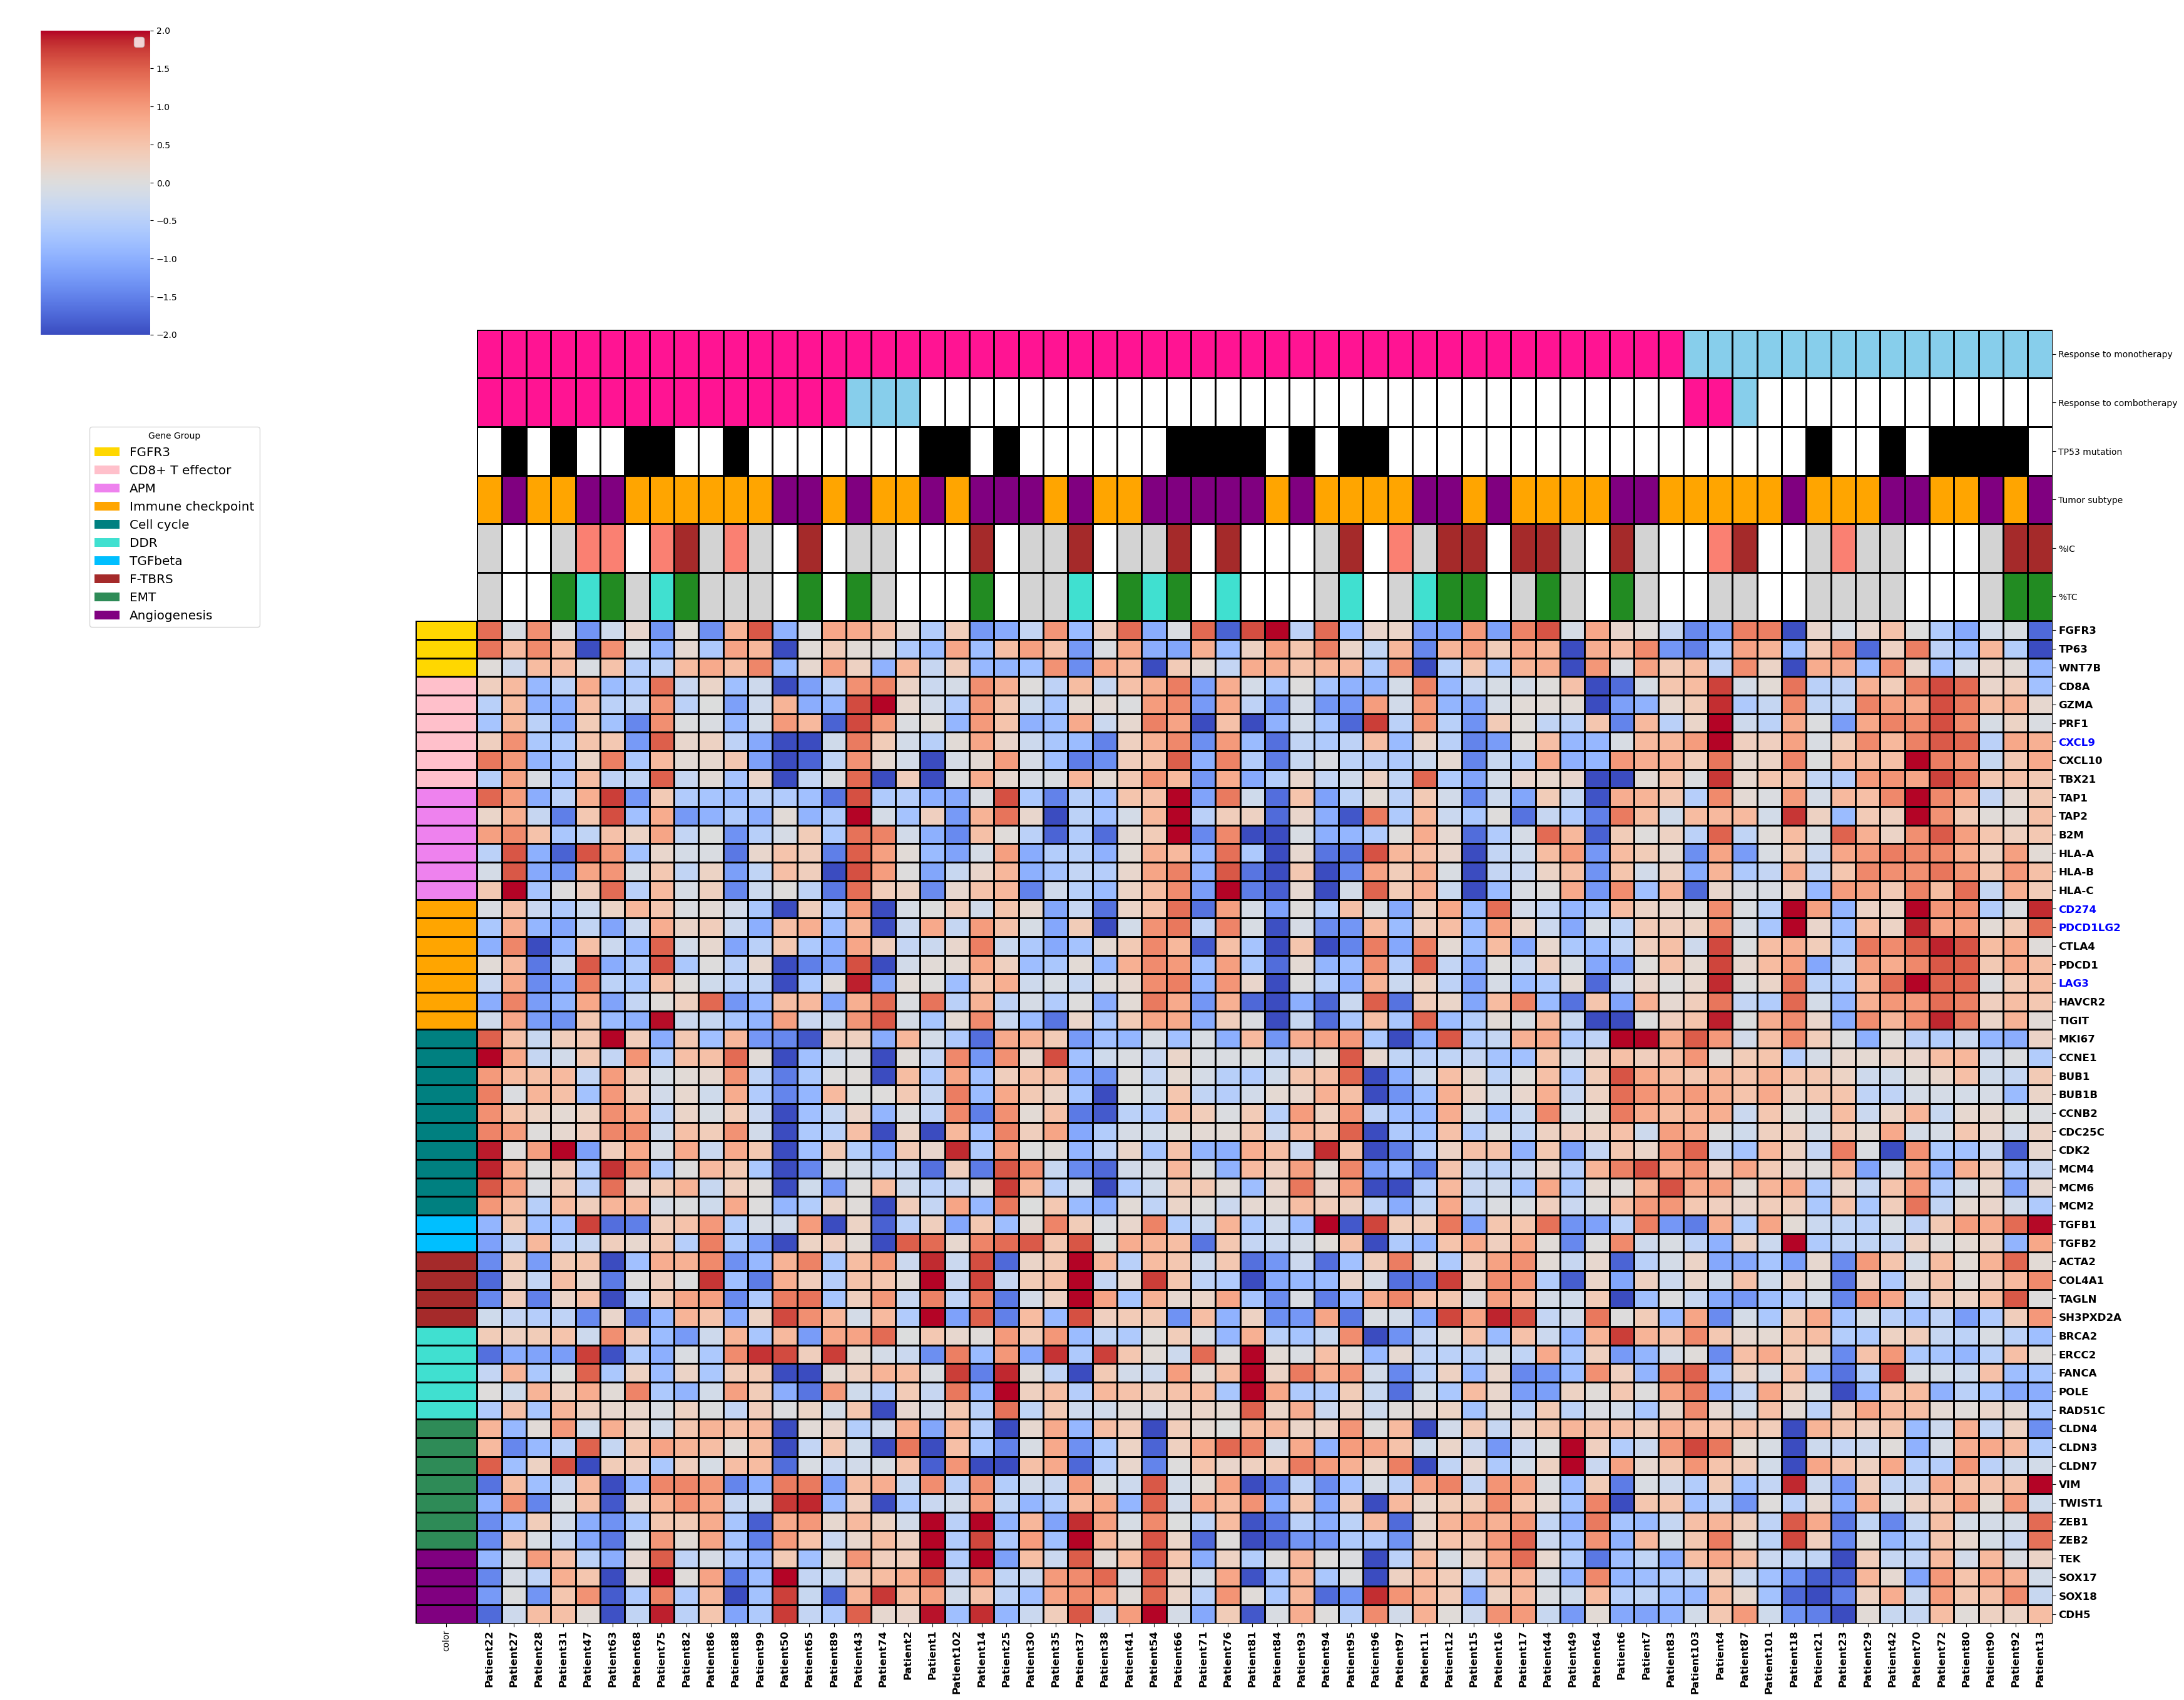

In [12]:
## Heatmap annotation
annot = m15126_exp[['response_color','combo_color', 
            'TP53_color',
            'subtype_color','IC_color','TC_color',]]
annot.columns= ['Response to monotherapy',
                'Response to combotherapy',
               'TP53 mutation','Tumor subtype','%IC','%TC'
               ]

## regroup by response
z_reordered = z.reindex(annot.sort_values(by=['Response to monotherapy', 'Response to combotherapy']).index)

# Create hatmap
f = sns.clustermap(z_reordered.T, 
               row_cluster = False, figsize=(35,27),
               row_colors = gdf[['color']], linewidth = 1, linecolor = 'black',
               col_cluster = False,
               vmin = -2, vmax= 2, cmap = 'coolwarm', col_colors = annot)

ax = f.ax_heatmap

## highlight significant genes
highlight = {"CXCL9": "blue",
             "CD274": "blue",
             "PDCD1LG2": "blue",
             "LAG3": "blue" }

for label in f.ax_heatmap.get_yticklabels():
    text = label.get_text()
    if text in highlight:
        label.set_color(highlight[text])
        label.set_fontweight('extra bold')   # optional
        label.set_fontsize(12)
    else:
        label.set_fontweight('bold')
        label.set_fontsize(12)

for pat in f.ax_heatmap.get_xticklabels():
    pat.set_fontweight('bold')   # optional
    pat.set_fontsize(12)  # optional
    
legend = plt.legend(fontsize='x-large', title_fontsize='20')

# Add legend
f.ax_heatmap.legend(
    handles=handles,
    fontsize='x-large',
    title="Gene Group",
    bbox_to_anchor=(-0.25, 1.2),
    loc="upper left"
)

plt.show()

In [ ]:
## output
f.savefig("../data/rna_seq_data/Figures/Figure2A_heatmap.png")

- TMB Barplot Prep

In [14]:
## TMB bar
## Data prep
tmb = pd.read_csv('../data/wes_summary_data/TMB_QC_Response.txt', sep="\t")
tmb.index = tmb.patient_name
tmb['log_n_missense'] = np.log(tmb['n_missense'])

## get patients in an order of heatmap above
patient_labels = [t.get_text() for t in f.ax_heatmap.get_xticklabels()]

## sanity check --> this number should be 60
tmb.index.intersection(patient_labels).shape ## overlap 60

## get tmb values of patients in heatmap
tmb_dict = {}
tmb_color_dict = {}
for h in patient_labels:
    if h in tmb.index:
        tmb_dict[h] = tmb.log_n_missense[h]
        if "FAIL" in tmb.QC_pass[h]:
            tmb_color_dict[h] = "white"
        else:
            tmb_color_dict[h] = "grey"
    else:
        tmb_dict[h] = None
        tmb_color_dict[h] = "white"


tmb_data = pd.Series(tmb_dict)

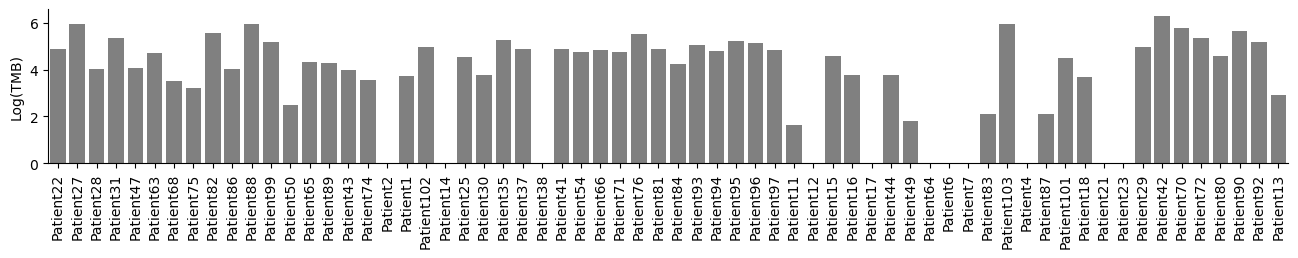

In [15]:
## TMB barplot
plt.subplots(figsize=(16,2))
sns.barplot(x=tmb_data.index, y=tmb_data.values, palette = tmb_color_dict, legend=True)
plt.ylabel('Log(TMB)')
plt.xlabel('')
plt.xticks(rotation = 90, )
sns.despine(top = True)
plt.show()

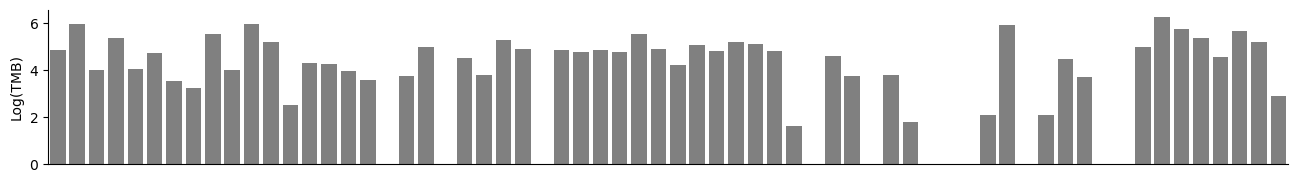

In [ ]:
## Same plot as above -> just omitting x-axis label
plt.subplots(figsize=(16,2))
sns.barplot(x=tmb_data.index, y=tmb_data.values, palette = tmb_color_dict, legend=True)
plt.ylabel('Log(TMB)')
plt.xlabel('')
plt.xticks([])
sns.despine(top = True)
## output
plt.savefig("../data/rna_seq_data/Figures/Figure2A_TMB_barplot.png", dpi=300, bbox_inches='tight')
plt.show()

- Heatmap other grouping legends

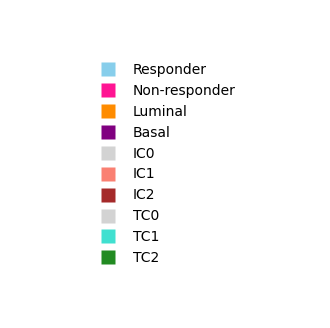

In [ ]:
## Heatmap legend (column annotation = patient group)
input_dict = {'Responder':'skyblue','Non-responder':'deeppink',
'Luminal':'darkorange','Basal':'purple',
'IC0':'lightgrey','IC1':'salmon','IC2':'brown',
'TC0':'lightgrey','TC1':'turquoise','TC2':'forestgreen'}

legend_elements = []
for k in input_dict.keys():
    legend_elements.append(Line2D([0], [0], marker='s',
                                  color='none', label=k,
                                  markerfacecolor=input_dict[k], 
                                  markeredgecolor='none', 
                                  markersize=10,
                                  linestyle='None'))

fig, ax = plt.subplots(figsize=(4,4))
ax.legend(handles=legend_elements, loc="center", frameon=False)
sns.despine(top=True, left=True, bottom=True)
plt.axis("off")
plt.grid(False)
plt.show()

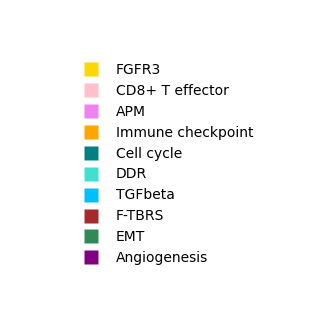

In [20]:
## Heatmap legend: row annotation (gene group)
input_dict = subtype_color_dict

legend_elements = []
for k in input_dict.keys():
    legend_elements.append(Line2D([0], [0], marker='s',
                                  color='none', label=k,
                                  markerfacecolor=input_dict[k], 
                                  markeredgecolor='none', 
                                  markersize=10,
                                  linestyle='None'))

fig, ax = plt.subplots(figsize=(4,4))
ax.legend(handles=legend_elements, loc="center", frameon=False)
sns.despine(top=True, left=True, bottom=True)
plt.axis("off")
plt.grid(False)
plt.show()


## Supplementary Figure S6

In [22]:
m15126_full

,Patient1,Patient2,Patient4,Patient6,Patient7,Patient11,Patient12,Patient13,Patient14,Patient15,...,Patient64,Patient76,Patient83,Patient86,Patient87,Patient94,Patient95,Patient101,Patient102,Patient103
ID,,,,,,,,,,,,,,,,,,,,,
TTN,327.809450,84.112597,85.772058,0.000000,10.875034,350.330371,21.732498,12.970131,11565.605362,2023.974398,...,3.551947e+01,72022.639312,49.784385,15.825224,50.273104,108.334374,6.439742,143.547352,25.295842,85.240011
NFIA,1671.965354,1925.735766,945.673287,1257.166933,1485.348404,1131.836584,314.603782,617.577776,1262.629071,609.957158,...,7.064428e+02,971.792840,141.719549,348.874250,611.550033,1057.707361,280.128773,686.634835,465.356259,1307.993277
MUC16,2.743175,366.332493,81.410767,14165.540171,71.593974,11.024382,1130.089900,0.000000,9.616368,9.592296,...,3.157286e+01,1279.587005,38.831820,0.719328,308.002306,18.193559,0.000000,5.981140,0.436135,24129.781583
SMAD2,2866.618204,2159.258896,3199.733905,2191.181503,1967.474915,1496.253666,2289.156464,2154.039449,2318.506238,2619.260986,...,1.432619e+03,1705.717567,3218.062642,1928.519305,1542.557003,2510.711139,2166.973153,1435.473522,1548.279963,2048.699581
FLRT2,1711.741396,859.940627,681.815175,169.915597,230.188221,2043.185522,1532.658555,343.209620,2002.127743,1052.331266,...,2.407431e+02,842.698588,145.038508,386.998652,106.909891,52.099737,209.291612,224.890852,430.029308,293.931073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000273748,0.000000,86.326086,23.987101,46.909214,67.062710,325.831744,7.244166,169.609405,81.739125,249.399689,...,6.709234e+01,108.773860,119.150628,108.618581,145.728364,113.296254,283.348644,267.955058,55.825306,92.098403
ENSG00000275063,0.000000,6.640468,778.490462,0.000000,1.812506,1381.722583,15.523213,55.871334,252.910469,48.525731,...,0.000000e+00,2.390634,128.111817,0.000000,7.636421,1.653960,0.000000,444.996792,13.956326,18.615635
MT-ND3,212371.146509,378861.950105,58124.380268,177921.436188,96064.613510,94919.319261,324812.881432,79205.596920,101105.527744,78486.420632,...,2.940783e+06,115352.885853,59905.882282,490840.892629,167889.893316,36561.610734,51164.822775,36447.868963,75445.283853,92987.054602


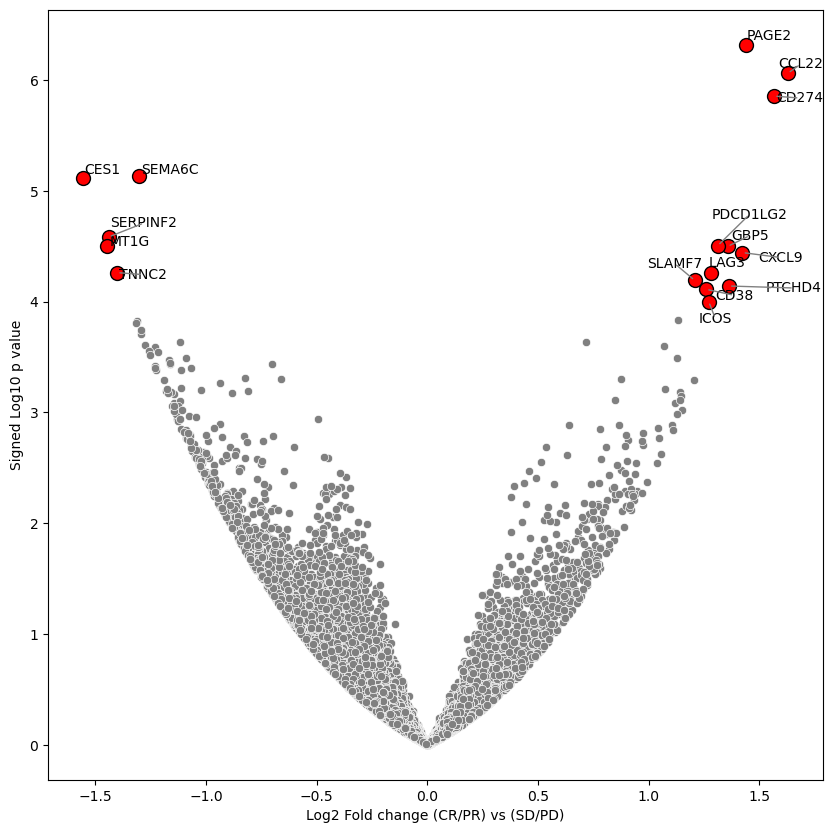

In [ ]:
exp_full = m15126
norm = m15126_full
norm['gene']= exp_full['ID']
exp_full['log10'] = -np.log10(exp_full['pvalue'])


plt.subplots(figsize=(10,10))
sns.scatterplot(data = exp_full[exp_full['padj']<0.1],edgecolor ='black', linewidth = 1, s = 100, x = 'log2FoldChange', y = 'log10', color = 'red')
sns.scatterplot(data = exp_full[exp_full['padj']>0.1],x = 'log2FoldChange', y = 'log10', color = 'grey')
plt.grid(False)
texts = []
for x, y, s in zip(exp_full[exp_full['padj']<0.1]['log2FoldChange'], 
                   exp_full[exp_full['padj']<0.1]['log10'],
                   exp_full[exp_full['padj']<0.1]['ID']):
    texts.append(plt.text(x,y, s, size= 10) )
plt.xlabel('Log2 Fold change (CR/PR) vs (SD/PD)')
plt.ylabel('Signed Log10 p value')

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='grey'),  expand_points=(1.2, 1.4),
    expand_text=(1.2, 1.4),
    force_text=0.5,
    force_points=0.3)

plt.savefig("../data/rna_seq_data/Figures/Supplemental_Figure_S6_a.png")
plt.show()

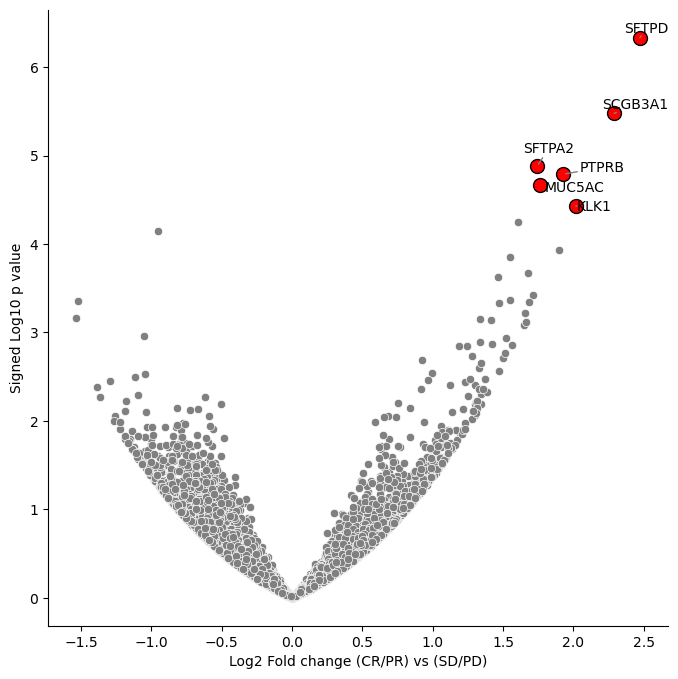

In [ ]:
combo = (pd.read_csv('../data/rna_seq_data/deseq_output/deseq_result_pc_combofull.csv', sep = ','))
combo['log10'] = -np.log10(combo['pvalue'])


plt.subplots(figsize=(8,8))
sns.scatterplot(data = combo[combo['padj']<0.1], edgecolor ='black', linewidth = 1, s = 100, x = 'log2FoldChange', y = 'log10', color = 'red')
sns.scatterplot(data = combo[combo['padj']>0.1], x = 'log2FoldChange', y = 'log10', color = 'grey')
plt.grid(False)
texts = []
for x, y, s in zip(combo[combo['padj']<0.1]['log2FoldChange'], 
                   combo[combo['padj']<0.1]['log10'],
                   combo[combo['padj']<0.1]['ID']):
    texts.append(plt.text(x,y, s, size= 10) )

plt.xlabel('Log2 Fold change (CR/PR) vs (SD/PD)')
plt.ylabel('Signed Log10 p value')
sns.despine(top = True)
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='grey'))
plt.savefig("../data/rna_seq_data/Figures/Supplemental_Figure_S6_b.png")
plt.show()